In [30]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm

import paths
from utils import get_bin_centers, import_sample, fits_to_pandas, binned_quantiles

plt.style.use(paths.styles / 'notebook.mplstyle')

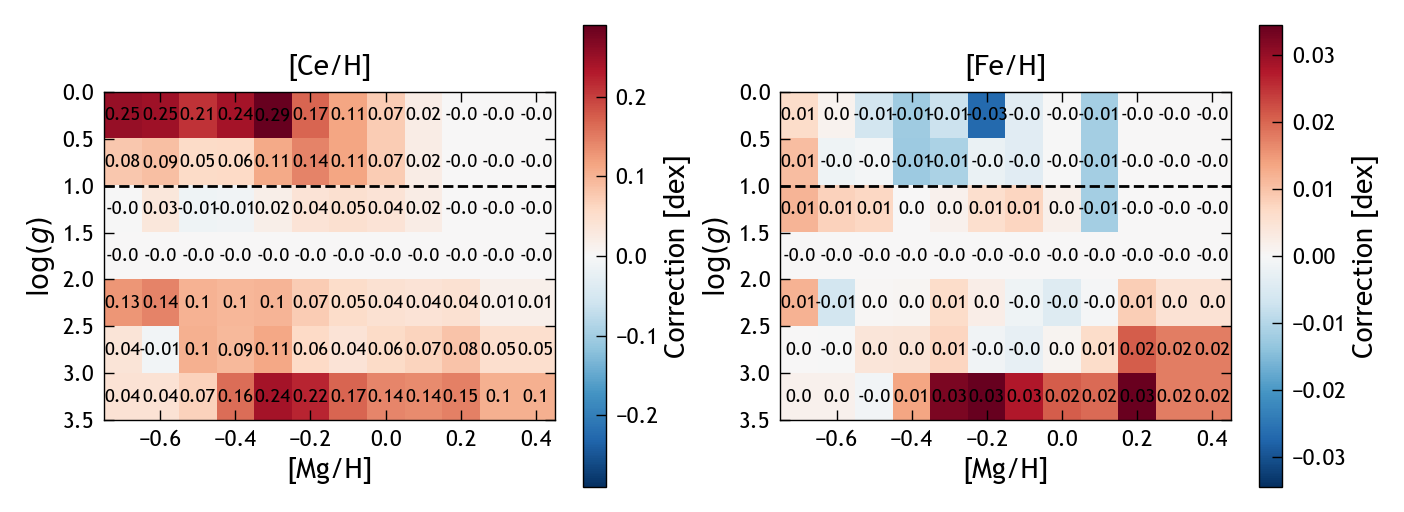

In [16]:
# Load calibration grids
fe_offsets = np.load(paths.data / 'fe_offset_grid.npy')
ce_offsets = np.load(paths.data / 'ce_offset_grid.npy')

# Initialize grid of log(g), [Mg/H] values
MgH_bin_edges = np.round(np.linspace(-0.75, 0.45, 13, endpoint=True), 2)
MgH_bin_centers = get_bin_centers(MgH_bin_edges)
logg_bin_edges = np.linspace(0, 3.5, 8, endpoint=True)
logg_bin_centers = get_bin_centers(logg_bin_edges)
grid = (MgH_bin_centers, logg_bin_centers)
MgH_grid = np.tile(MgH_bin_centers, (len(logg_bin_centers), 1))
logg_grid = np.tile(logg_bin_centers[:,np.newaxis], (len(MgH_bin_centers)))

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
aspect = 0.25
cmap = 'RdBu_r'
img = axs[0].imshow(
    ce_offsets.T, 
    aspect=aspect,
    origin='lower',
    cmap=cmap, 
    norm=CenteredNorm(vcenter=0),
    extent=[MgH_bin_edges[0], MgH_bin_edges[-1], logg_bin_edges[0], logg_bin_edges[-1]]
)
fig.colorbar(img, ax=axs[0], label=r'Correction [dex]')
for i, offset in enumerate(ce_offsets.T.flatten()):
    axs[0].text(
        MgH_grid.flatten()[i], 
        logg_grid.flatten()[i], 
        round(offset, 2), 
        va='center', ha='center',
        size='small'
    )
axs[0].axhline(1, color='k', linestyle='--')
axs[0].set_xlabel('[Mg/H]')
axs[0].set_ylabel(r'$\log(g)$')
axs[0].yaxis.set_inverted(True)
axs[0].set_title('[Ce/H]')

img = axs[1].imshow(
    fe_offsets.T, 
    aspect=aspect,
    origin='lower',
    cmap=cmap, 
    norm=CenteredNorm(vcenter=0),
    extent=[MgH_bin_edges[0], MgH_bin_edges[-1], logg_bin_edges[0], logg_bin_edges[-1]]
)
fig.colorbar(img, ax=axs[1], label=r'Correction [dex]')
for i, offset in enumerate(fe_offsets.T.flatten()):
    axs[1].text(
        MgH_grid.flatten()[i], 
        logg_grid.flatten()[i], 
        round(offset, 2), 
        va='center', ha='center',
        size='small'
    )
axs[1].axhline(1, color='k', linestyle='--')
axs[1].set_xlabel('[Mg/H]')
axs[1].set_ylabel(r'$\log(g)$')
axs[1].yaxis.set_inverted(True)
axs[1].set_title('[Fe/H]')
plt.show()

## Comparison with BAWLAS abundances

In [7]:
bawlas = fits_to_pandas(paths.data / 'catalogs' / 'dr17_nc_abund_v2_0.fits')
bawlas

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/astropy/io/fits/connect.py:215: AstropyUserWarning: hdu= was not specified but multiple tables are present, reading in first available table (hdu=1)
  warnings.warn(


,APOGEE_ID,FIELD,TELESCOPE,EXTRATARG,SNR,TEFF,LOGG,M_H,ALPHA_M,FE_H,...,ND_FE,ND_FE_ERR_MEAS,ND_FE_ERR_EMP,ND_FE_LIM,ND_N_LINES,C12C13,C12C13_ERR_MEAS,C12C13_ERR_EMP,C12C13_LIM,C12C13_N_LINES
0,2M00000506+5656353,NGC7789_MGA,apo25m,16,525.623474,4975.688965,2.483590,-0.423260,0.083166,-0.430830,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,1.088897,0
1,2M00000506+5656353,NGC7789_btx,apo25m,0,531.008667,4981.524902,2.527178,-0.415990,0.081501,-0.427070,...,NaN,NaN,NaN,0.77551,0,NaN,NaN,NaN,1.454339,0
2,2M00000535+1504343,105-45,apo25m,0,167.626755,4914.675293,3.300560,-0.088788,0.075476,-0.087559,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
3,2M00000546+6152107,116+00,apo25m,0,822.305420,4073.770020,1.281504,-0.270330,0.055308,-0.283400,...,0.012733,0.076613,0.040393,NaN,3,12.914200,1.145599,1.138946,NaN,5
4,2M00000644+5733530,NGC7789_MGA,apo25m,0,171.191010,4757.323242,2.575232,-0.058700,-0.011500,-0.065082,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,4.462258,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126357,AP18135083-3102184,000-06-C,lco25m,1,162.471573,3944.117920,1.411645,0.163740,0.032307,0.167700,...,-0.119200,0.049052,0.054067,NaN,2,14.903500,2.290675,1.386121,NaN,6
126358,AP18135859-3104469,000-06-C,lco25m,1,154.032410,4390.317871,2.172430,0.349270,0.029150,0.333440,...,-0.231440,0.024457,0.055782,NaN,1,10.427800,1.751634,1.079083,NaN,5
126359,AP18140813-3113558,000-06-C,lco25m,1,174.579102,3917.883301,1.335646,0.074230,0.072061,0.062466,...,-0.252799,0.040075,0.044166,NaN,3,14.220667,1.002714,1.246086,NaN,6
126360,AP18151304-3116170,000-06-C,lco25m,1,194.814880,4130.403809,1.761014,0.158400,0.046563,0.157610,...,-0.210943,0.059712,0.048287,NaN,3,14.071333,1.592463,1.391191,NaN,6


In [44]:
sample = import_sample(good_ages=False, cut_limits=True)

In [57]:
bawlas_dr19 = sample.join(bawlas.set_index(['APOGEE_ID', 'FIELD', 'TELESCOPE']), on=['sdss4_apogee_id', 'field', 'telescope'])
bawlas_dr19['CE_H'] = bawlas_dr19['CE_FE'] + bawlas_dr19['FE_H']
bawlas_dr19['CE_H_LIM'] = bawlas_dr19['CE_FE_LIM'] + bawlas_dr19['FE_H']
bawlas_dr19['ce_fe'] = bawlas_dr19['ce_h'] - bawlas_dr19['fe_h']
bawlas_dr19['ce_fe_corr'] = bawlas_dr19['ce_h_corr'] - bawlas_dr19['fe_h_corr']
bawlas_dr19

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,ND_FE_ERR_EMP,ND_FE_LIM,ND_N_LINES,C12C13,C12C13_ERR_MEAS,C12C13_ERR_EMP,C12C13_LIM,C12C13_N_LINES,CE_H,CE_H_LIM
sdss_id,,,,,,,,,,,,,,,,,,,,,
54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,27021597851161007,...,0.040844,NaN,1.0,9.982333,1.148594,0.973595,NaN,3.0,-0.10725,NaN
54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,27021597851161095,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,27021597851160855,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,27021597851164071,...,0.049912,NaN,2.0,14.725667,1.498215,1.660177,NaN,3.0,0.04025,NaN
54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,27021597851163901,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,27021599359029628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,27021599365533938,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,27021599358122770,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
bawlas_dr19[bawlas_dr19['CE_FE'].notna()]

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,ND_FE_ERR_MEAS,ND_FE_ERR_EMP,ND_FE_LIM,ND_N_LINES,C12C13,C12C13_ERR_MEAS,C12C13_ERR_EMP,C12C13_LIM,C12C13_N_LINES,CE_H
sdss_id,,,,,,,,,,,,,,,,,,,,,
54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,27021597851161007,...,0.204169,0.040844,NaN,1.0,9.982333,1.148594,0.973595,NaN,3.0,-0.107250
54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,27021597851164071,...,0.086942,0.049912,NaN,2.0,14.725667,1.498215,1.660177,NaN,3.0,0.040250
54382034,2M00210928+5637303,421565131898046208,421565131898046208,403306770,16025,gaia_dr3_source,31,63050394783224501,4291612469,27021597850895895,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,4.655062,0.0,-0.211333
54382057,2M00204324+5638335,421566918604422144,421566918604422144,403306732,16025,gaia_dr3_source,31,63050394783225099,4291612137,27021597850895563,...,NaN,NaN,0.691680,0.0,NaN,NaN,NaN,1.532549,0.0,-0.141000
54382093,2M00215551+5639362,421570388938149504,421570388938149504,403316792,16025,gaia_dr3_source,31,63050394783226205,4291878306,27021597851160797,...,NaN,NaN,NaN,0.0,11.914333,1.108696,1.237154,NaN,3.0,-0.409750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129054607,2M14032335-6120515,5866393098309452032,5866393098309452032,328217027,184776,gaia_dr3_source,31,63050396108650386,5632092449,27021599188115197,...,0.140313,0.050970,NaN,1.0,4.908333,1.148346,0.529157,NaN,3.0,0.048000
129056512,2M09162501-4758008,5326459251831658240,5326459251831658240,391630580,171018,gaia_dr3_source,31,63050395876070656,5802207335,27021599358030195,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2.349590,0.0,-0.017000
129057199,2M17274943-3204441,4057793158900209280,4057793158900209280,161127131,150644,gaia_dr3_source,31,63050395289104687,4714725632,27021598271580803,...,NaN,NaN,-0.238827,0.0,NaN,NaN,NaN,NaN,0.0,-0.037000


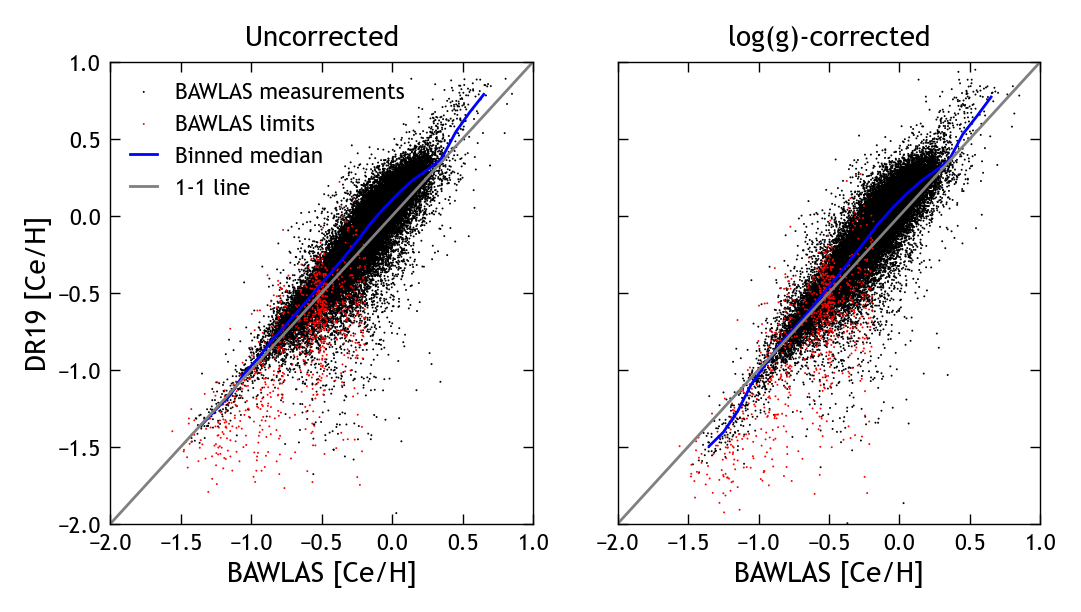

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

kwargs = dict(
    rasterized=True, s=0.5, edgecolors='none'
)
titles = ['Uncorrected', 'log(g)-corrected']
axlim = (-2, 1)
bin_edges = np.arange(axlim[0], axlim[1], 0.1)
for i, sdss5_col in enumerate(['ce_h', 'ce_h_corr']):
    axs[i].scatter(bawlas_dr19['CE_H'], bawlas_dr19[sdss5_col], c='k', label='BAWLAS measurements', **kwargs)
    axs[i].scatter(bawlas_dr19['CE_H_LIM'], bawlas_dr19[sdss5_col], c='r', label='BAWLAS limits', **kwargs)
    binned_medians = binned_quantiles(
        bawlas_dr19, sdss5_col, 'CE_H', 
        q=0.5, bin_edges=bin_edges, min_count=10
    )
    axs[i].plot(*binned_medians, 'b-', label='Binned median')
    axs[i].set_xlabel('BAWLAS [Ce/H]')
    axs[i].set_title(titles[i])
    axs[i].plot(axlim, axlim, c='gray', label='1-1 line')
axs[0].set_ylabel('DR19 [Ce/H]')
axs[0].set_xlim(axlim)
axs[0].set_ylim(axlim)
axs[0].legend(loc='upper left')
plt.show()

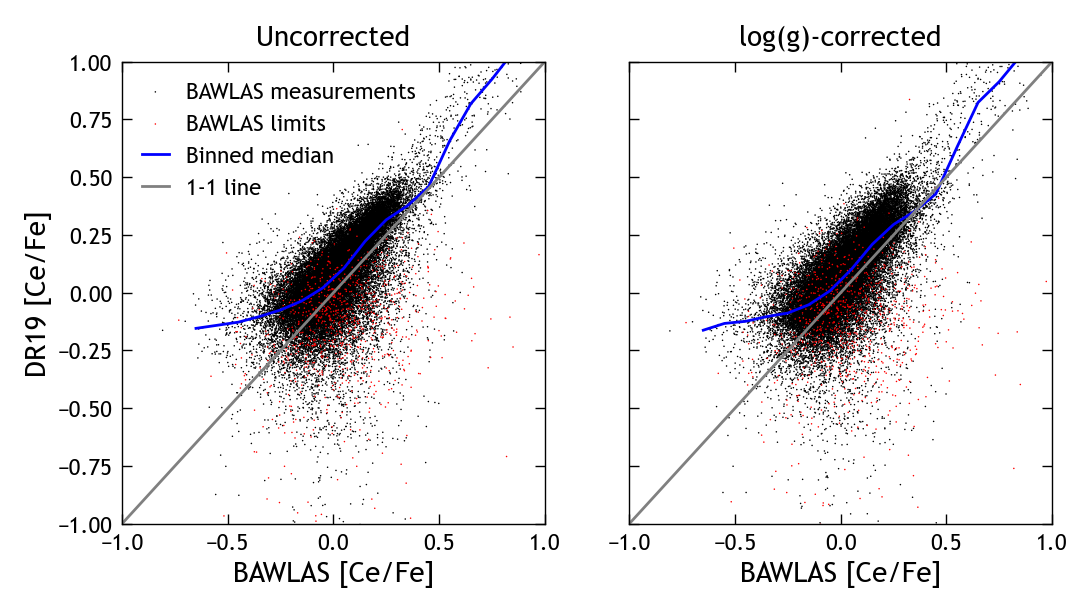

In [64]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

kwargs = dict(
    rasterized=True, s=0.3, edgecolors='none'
)
titles = ['Uncorrected', 'log(g)-corrected']
axlim = (-1, 1)
bin_edges = np.arange(axlim[0], axlim[1], 0.1)
for i, sdss5_col in enumerate(['ce_fe', 'ce_fe_corr']):
    axs[i].scatter(bawlas_dr19['CE_FE'], bawlas_dr19[sdss5_col], c='k', label='BAWLAS measurements', **kwargs)
    axs[i].scatter(bawlas_dr19['CE_FE_LIM'], bawlas_dr19[sdss5_col], c='r', label='BAWLAS limits', **kwargs)
    binned_medians = binned_quantiles(
        bawlas_dr19, sdss5_col, 'CE_FE', 
        q=0.5, bin_edges=bin_edges, min_count=10
    )
    axs[i].plot(*binned_medians, 'b-', label='Binned median')
    axs[i].set_xlabel('BAWLAS [Ce/Fe]')
    axs[i].set_title(titles[i])
    axs[i].plot(axlim, axlim, c='gray', label='1-1 line')
axs[0].set_ylabel('DR19 [Ce/Fe]')
axs[0].set_xlim(axlim)
axs[0].set_ylim(axlim)
axs[0].legend(loc='upper left')
plt.show()